In [1]:
# ==================================================================
# TECH CHALLENGE - CLASSIFICAÇÃO E CLUSTERIZAÇÃO DE ATRASOS DE VOOS
# ==================================================================
# Autor: Veronica Rocha
# Data: 24/03/2026
# Descrição: Pipeline completo com modelo supervisionado e clusterização  
# ==================================================================

# ==================================================================
# 0. CONFIGURAÇÕES INICIAIS E IMPORTS
# ==================================================================
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["JOBLIB_TEMP_FOLDER"] = "/tmp"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_auc_score, roc_curve,
                             silhouette_score)

# VERIFICADOR DE DEPENDÊNCIAS - Instala pacotes faltantes
try:
    import xgboost
    import category_encoders
    import lightgbm
    print("Todos os pacotes necessários já estão instalados.")
except ImportError as e:
    print(f"!! Pacote faltando: {e}")
    print("Instalando...")
    import sys
    !{sys.executable} -m pip install xgboost category_encoders lightgbm -q
    print("Instalação concluída!")
    
    # Reimporta após instalação
    import xgboost
    import category_encoders
    import lightgbm

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from category_encoders import TargetEncoder

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("="*70)
print("TECH CHALLENGE – ANÁLISE E MODELAGEM DE ATRASOS DE VOOS")
print("="*70)



Todos os pacotes necessários já estão instalados.
TECH CHALLENGE – ANÁLISE E MODELAGEM DE ATRASOS DE VOOS


In [8]:
flights = pd.read_csv('flights.csv')
print(flights.sample(10))

         YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
5163610  2015     11   19            4      B6             49      N238JB   
237338   2015      1   16            5      OO           6446      N117SY   
3002203  2015      7    7            2      AA            697      N901AW   
5388109  2015     12    4            5      AA            403      N678AW   
943836   2015      3    3            2      F9            780      N932FR   
740187   2015      2   18            3      F9           1055      N953FR   
5590166  2015     12   17            4      WN           3197      N202WN   
4354646  2015      9   29            2      AS            558      N792AS   
5785843  2015     12   29            2      UA            450      N446UA   
105509   2015      1    7            3      AA           1156      N3MEAA   

        ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  \
5163610            BOS                 SAV                 1115   
237338            

In [2]:
# ==================================================================
# 1. CARREGAMENTO DOS DADOS
# ==================================================================
colunas_flights = [
    'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK',
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'DISTANCE',
    'DEPARTURE_DELAY', 'CANCELLED', 'DIVERTED'
]

print("\n1. Carregando dados de voos...")
flights = pd.read_csv('flights.csv', usecols=colunas_flights)
print(f"Voos carregados: {len(flights):,}")


1. Carregando dados de voos...
Voos carregados: 5,819,079


In [7]:
print(flights.sample(10))

         YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE ORIGIN_AIRPORT  \
4967055  2015     11    6            5      MQ            LIT   
1289685  2015      3   25            3      UA            LAX   
3284203  2015      7   24            5      WN            MCO   
625481   2015      2   11            3      DL            ATL   
2245797  2015      5   22            5      B6            LAX   
3918885  2015      8   31            1      WN            DCA   
3008614  2015      7    8            3      EV            OAJ   
5744416  2015     12   27            7      NK            MYR   
2648031  2015      6   16            2      DL            MEM   
3501112  2015      8    6            4      MQ            DFW   

        DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  DEPARTURE_DELAY  DISTANCE  \
4967055                 ORD                 1910             65.0       552   
1289685                 ORD                  600              5.0      1744   
3284203                 RDU                 144

In [3]:
# ==================================================================
# 2. REMOÇÃO DE CANCELADOS E DESVIADOS
# ==================================================================
print("\n2. Removendo os voos cancelados e desviados...")
cancelados = flights['CANCELLED'].sum()
desviados = flights['DIVERTED'].sum()
print(f" Cancelados: {cancelados:,} ({cancelados/len(flights)*100:.2f}%)")
print(f"Desviados: {desviados:,} ({desviados/len(flights)*100:.2f}%)")

flights = flights[(flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)]
flights = flights.drop(columns=['CANCELLED', 'DIVERTED'])
print(f"Voos válidos: {len(flights):,}")


2. Removendo os voos cancelados e desviados...
 Cancelados: 89,884 (1.54%)
Desviados: 15,187 (0.26%)
Voos válidos: 5,714,008


In [4]:
# ==================================================================
# 3. TRATAMENTO DE VALORES AUSENTES
# ==================================================================
targets = ['DEPARTURE_DELAY']

missing = flights.isnull().sum()
missing_pct = (missing / len(flights)) * 100
missing_df = pd.DataFrame({'Coluna': flights.columns, 'Ausentes': missing, 'Percentual': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0].sort_values('Percentual', ascending=False)

print("\n3. Tratamento de valores ausentes...")
if missing_df.empty:
    print(" Nenhum valor ausente.")
else:
    print("Valores ausentes encontrados:")
    print(missing_df)
    
    for _, row in missing_df.iterrows():
        col = row['Coluna']
        pct = row['Percentual']
        
        if col in targets:
            print(f" Target '{col}' ({pct:.2f}%) – removendo linhas")
            flights = flights.dropna(subset=[col])
        
        elif pct < 3:
            print(f" Feature '{col}' ({pct:.2f}%) – removendo linhas")
            flights = flights.dropna(subset=[col])
        
        elif pct > 4:
            print(f"Feature '{col}' ({pct:.2f}%) – imputando...")
            if col in flights.select_dtypes(include=[np.number]).columns:
                valor = flights[col].median()
                metodo = "mediana"
                flights[col] = flights[col].fillna(valor)
                print(f"- Preenchido com {metodo} = {valor:.2f}")
            else:
                moda = flights[col].mode()[0]
                flights[col] = flights[col].fillna(moda)
                print(f" - Preenchido com moda = {moda}")
        
        else:
            print(f" Feature '{col}' ({pct:.2f}%) – removendo linhas (3-4%)")
            flights = flights.dropna(subset=[col])

print(f"Shape após tratamento: {flights.shape}")


3. Tratamento de valores ausentes...
 Nenhum valor ausente.
Shape após tratamento: (5714008, 11)


In [5]:
# ==================================================================
# 4. ENRIQUECIMENTO COM DADOS DE AEROLINHAS E AEROPORTOS
# ==================================================================
print("\n4. Adicionando dados de airlines e airports...")
airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')

flights = flights.merge(airlines[['IATA_CODE', 'AIRLINE']], 
                        left_on='AIRLINE', right_on='IATA_CODE', 
                        how='left', suffixes=('', '_NAME'))
flights.drop('IATA_CODE', axis=1, inplace=True)

airports_origin = airports[['IATA_CODE', 'STATE']].rename(columns={'IATA_CODE': 'ORIGIN_AIRPORT'})
flights = flights.merge(airports_origin, on='ORIGIN_AIRPORT', how='left')
flights.rename(columns={'STATE': 'ORIGIN_STATE'}, inplace=True)

airports_dest = airports[['IATA_CODE', 'STATE']].rename(columns={'IATA_CODE': 'DESTINATION_AIRPORT'})
flights = flights.merge(airports_dest, on='DESTINATION_AIRPORT', how='left')
flights.rename(columns={'STATE': 'DEST_STATE'}, inplace=True)

print("OK Dados complementares adicionados.")


4. Adicionando dados de airlines e airports...
OK Dados complementares adicionados.


In [6]:
# ==================================================================
# 5. ENGENHARIA DE FEATURES
# ==================================================================
print("\n5. Criando features derivadas...")

def periodo_dia(hora):
    if pd.isna(hora):
        return 'desconhecido'
    h = int(hora) // 100
    if 5 <= h < 12:
        return 'manha'
    elif 12 <= h < 18:
        return 'tarde'
    elif 18 <= h <= 23:
        return 'noite'
    else:
        return 'madrugada'

flights['PERIODO'] = flights['SCHEDULED_DEPARTURE'].apply(periodo_dia)

def estacao(mes):
    if mes in [12, 1, 2]:
        return 'inverno'
    elif mes in [3, 4, 5]:
        return 'primavera'
    elif mes in [6, 7, 8]:
        return 'verao'
    else:
        return 'outono'

flights['ESTACAO'] = flights['MONTH'].apply(estacao)
flights['FIM_DE_SEMANA'] = flights['DAY_OF_WEEK'].isin([6, 7]).astype(int)
flights['HORA_PROGRAMADA'] = (flights['SCHEDULED_DEPARTURE'] // 100).astype(int)

# Dia do ano
flights['DAY_OF_YEAR'] = pd.to_datetime(flights[['YEAR','MONTH','DAY']]).dt.dayofyear

# Feriados nos EUA em 2015
feriados_2015 = [
    '2015-01-01', '2015-01-19', '2015-02-16', '2015-05-25',
    '2015-07-04', '2015-09-07', '2015-10-12', '2015-11-11',
    '2015-11-26', '2015-12-25'
]
flights['DATA'] = pd.to_datetime(flights[['YEAR','MONTH','DAY']])
flights['FERIADO'] = flights['DATA'].isin(pd.to_datetime(feriados_2015)).astype(int)
flights.drop('DATA', axis=1, inplace=True)

# Interação hora * estação
flights['HORA_ESTACAO'] = flights['HORA_PROGRAMADA'].astype(str) + '_' + flights['ESTACAO']

# Target binária
flights['ATRASO_15'] = (flights['DEPARTURE_DELAY'] > 15).astype(int)

# Removendo YEAR (pq é constante)
flights = flights.drop(columns=['YEAR'])

print(" Features criadas: PERIODO, ESTACAO, FIM_DE_SEMANA, HORA_PROGRAMADA, DAY_OF_YEAR, FERIADO, HORA_ESTACAO, ATRASO_15")


5. Criando features derivadas...
 Features criadas: PERIODO, ESTACAO, FIM_DE_SEMANA, HORA_PROGRAMADA, DAY_OF_YEAR, FERIADO, HORA_ESTACAO, ATRASO_15


In [7]:
# ==================================================================
# 6. AMOSTRAGEM BALANCEADA POR MÊS
# ==================================================================
EXEMPLOS_POR_CLASSE_POR_MES = 11000

print(f"\n6. Amostragem balanceada por mês ({EXEMPLOS_POR_CLASSE_POR_MES} de cada classe/mês)...")
amostras = []
for mes in sorted(flights['MONTH'].unique()):
    df_mes = flights[flights['MONTH'] == mes]
    df_atraso = df_mes[df_mes['ATRASO_15'] == 1]
    df_nao = df_mes[df_mes['ATRASO_15'] == 0]
    
    n_atraso = min(EXEMPLOS_POR_CLASSE_POR_MES, len(df_atraso))
    n_nao = min(EXEMPLOS_POR_CLASSE_POR_MES, len(df_nao))
    
    amostra_atraso = df_atraso.sample(n=n_atraso, random_state=42) if n_atraso else pd.DataFrame()
    amostra_nao = df_nao.sample(n=n_nao, random_state=42) if n_nao else pd.DataFrame()
    
    amostra_mes = pd.concat([amostra_atraso, amostra_nao], ignore_index=True)
    amostras.append(amostra_mes)
    print(f" Mês {mes}: atrasados {n_atraso}/{len(df_atraso)} | não {n_nao}/{len(df_nao)}")

df = pd.concat(amostras, ignore_index=True)
print(f" Amostra final: {len(df):,} registros")
print(f" Proporção de atrasos: {df['ATRASO_15'].mean():.1%}")


6. Amostragem balanceada por mês (11000 de cada classe/mês)...
 Mês 1: atrasados 11000/87212 | não 11000/369801
 Mês 2: atrasados 11000/87452 | não 11000/320211
 Mês 3: atrasados 11000/91250 | não 11000/400888
 Mês 4: atrasados 11000/76043 | não 11000/403208
 Mês 5: atrasados 11000/85855 | não 11000/403786
 Mês 6: atrasados 11000/112128 | não 11000/380719
 Mês 7: atrasados 11000/105492 | não 11000/408892
 Mês 8: atrasados 11000/92384 | não 11000/411572
 Mês 9: atrasados 11000/55844 | não 11000/406309
 Mês 10: atrasados 11000/57458 | não 11000/425420
 Mês 11: atrasados 11000/66544 | não 11000/395823
 Mês 12: atrasados 11000/93925 | não 11000/375792
 Amostra final: 264,000 registros
 Proporção de atrasos: 50.0%



7. ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)

1. QUAIS AEROPORTOS SÃO MAIS CRÍTICOS EM RELAÇÃO A ATRASOS?

Top 10 aeroportos com mais atrasos:
   1. 12255 - nan: 100.0%
   2. 10165 - nan: 100.0%
   3. 11097 - nan: 100.0%
   4. DLG - Dillingham/AK: 100.0%
   5. 11471 - nan: 100.0%
   6. 15041 - nan: 100.0%
   7. 10581 - nan: 100.0%
   8. 12511 - nan: 100.0%
   9. 10577 - nan: 100.0%
   10. 10141 - nan: 100.0%

2. QUE CARACTERÍSTICAS AUMENTAM A CHANCE DE ATRASO?

Atrasos por período do dia:
   madrugada: 45.9%
   manha: 36.2%
   tarde: 54.8%
   noite: 61.4%

Atrasos por estação:
   primavera: 50.0%
   verao: 50.0%
   outono: 50.0%
   inverno: 50.0%

Horário de maior atraso: 20h (62.7%)
Horário de menor atraso: 5h (21.0%)

3. ATRASOS SÃO MAIS COMUNS EM CERTOS DIAS DA SEMANA OU HORÁRIOS?
----------------------------------------

Atrasos por dia da semana:
   Segunda: 51.7%
   Terça: 49.0%
   Quarta: 48.7%
   Quinta: 51.6%
   Sexta: 51.2%
   Sábado: 46.5%
   Domingo: 50.3%

Análise de horários:

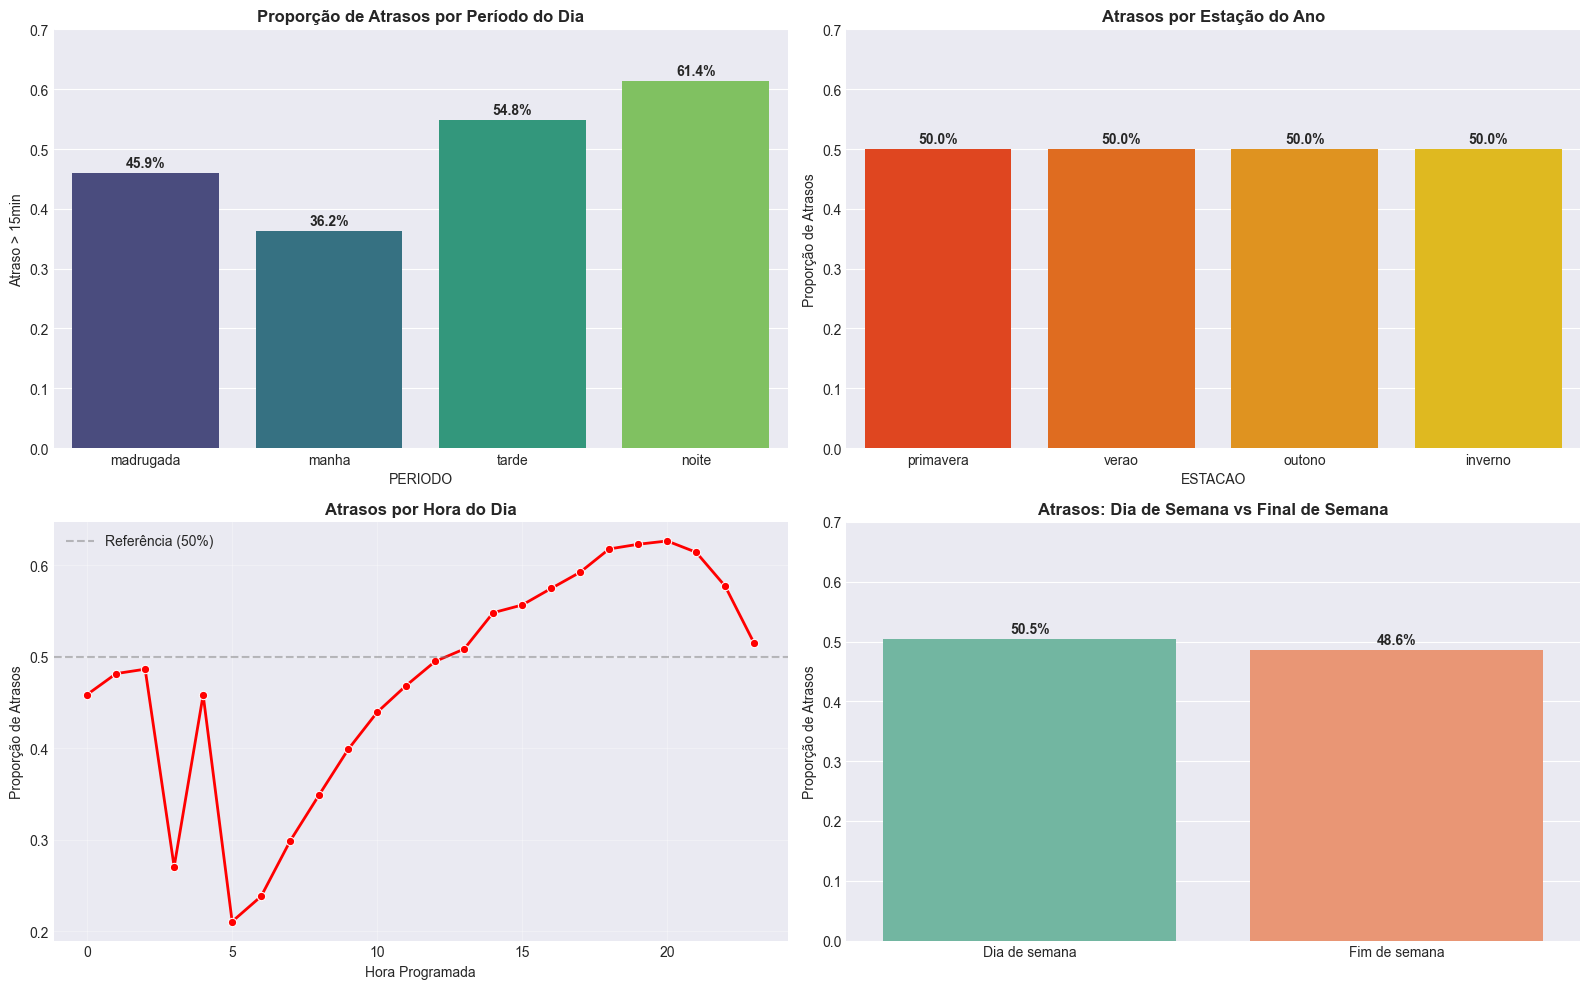


7.2 Top 20 Aeroportos com mais atrasos


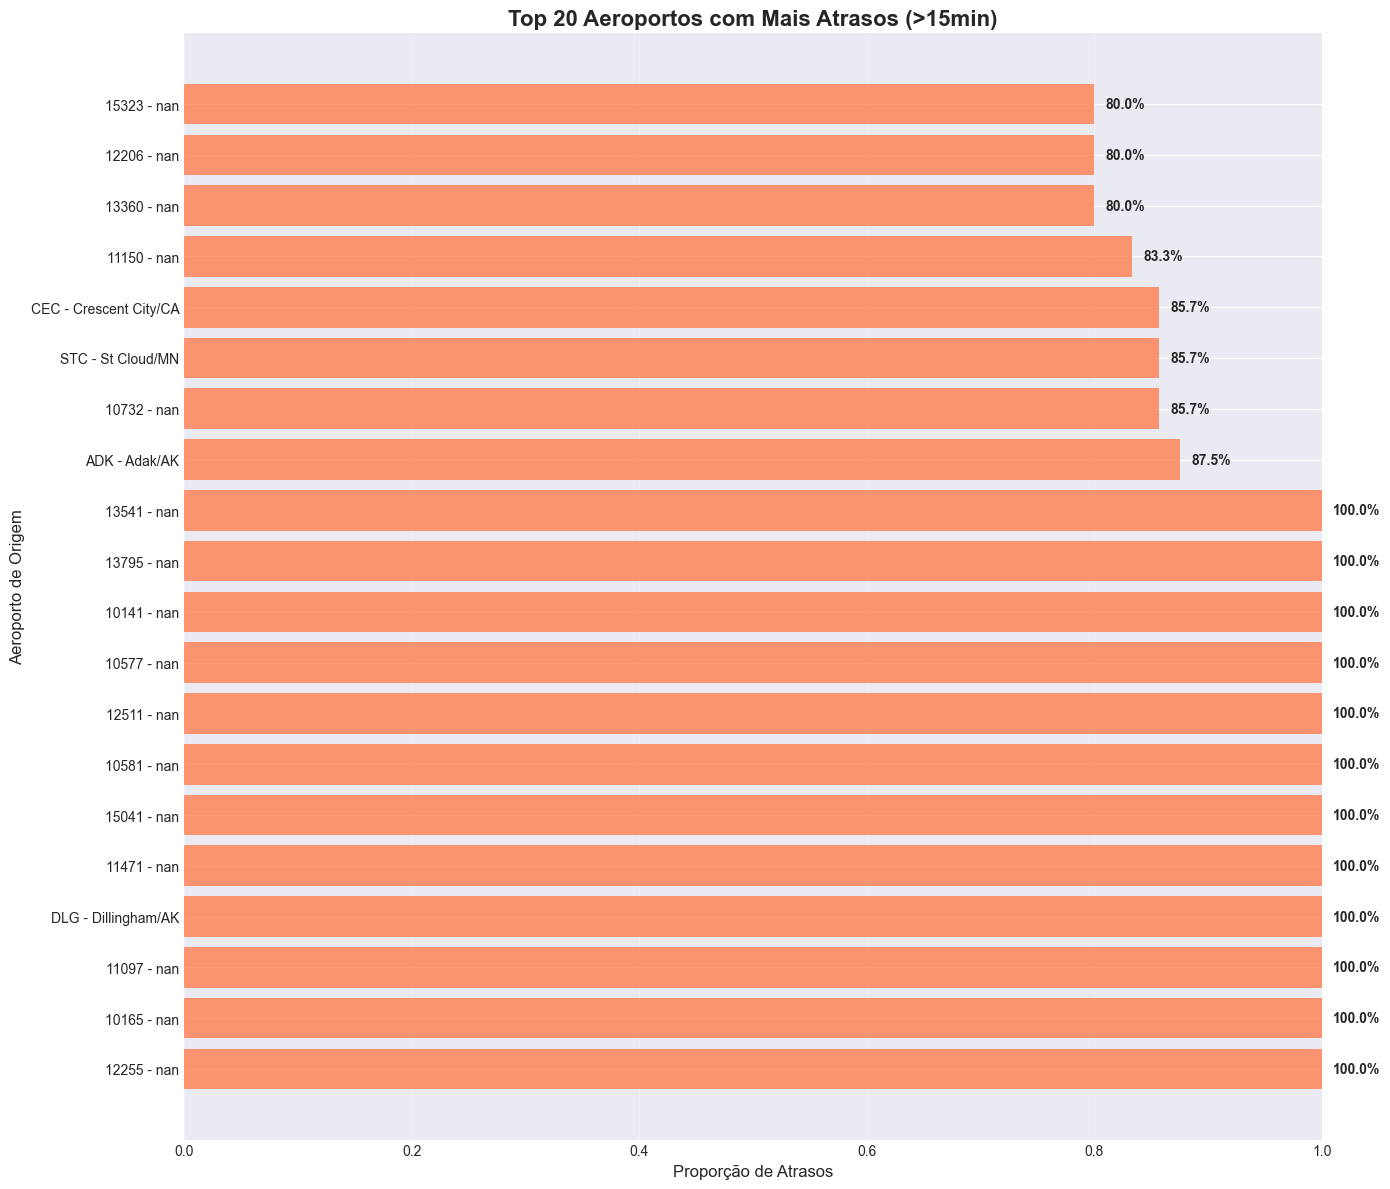


7.3 Top 20 Companhias com mais atrasos


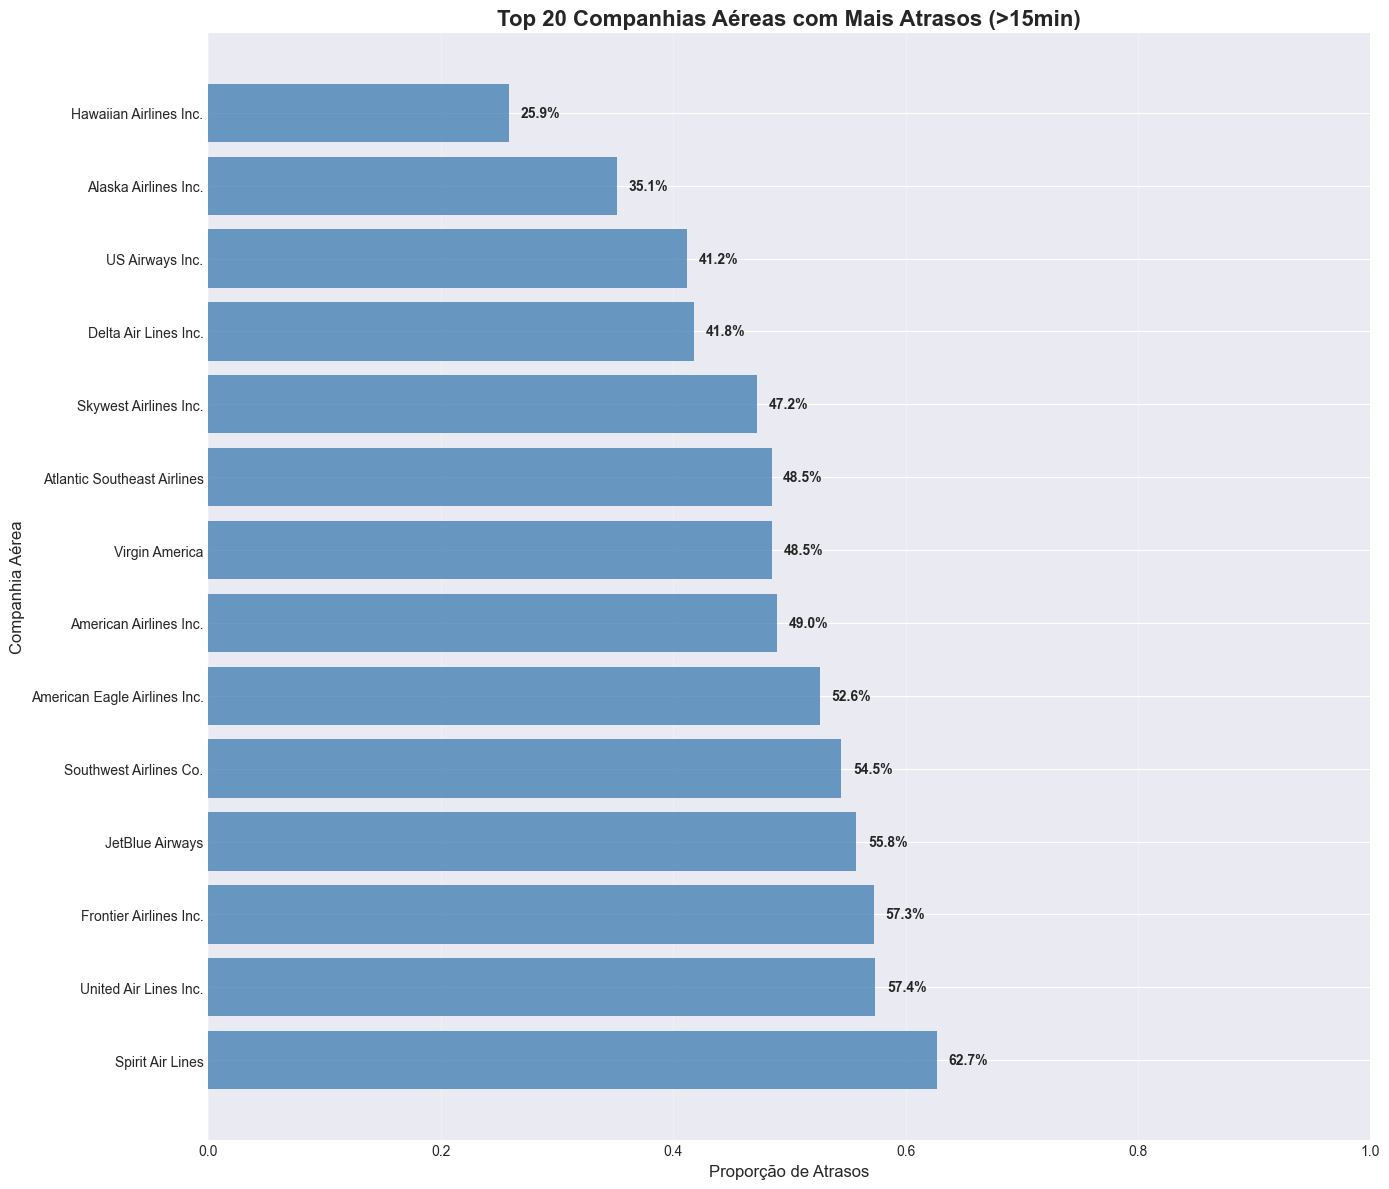


7.4 Mapa de Calor: Top 10 Aeroportos × Companhias Aéreas


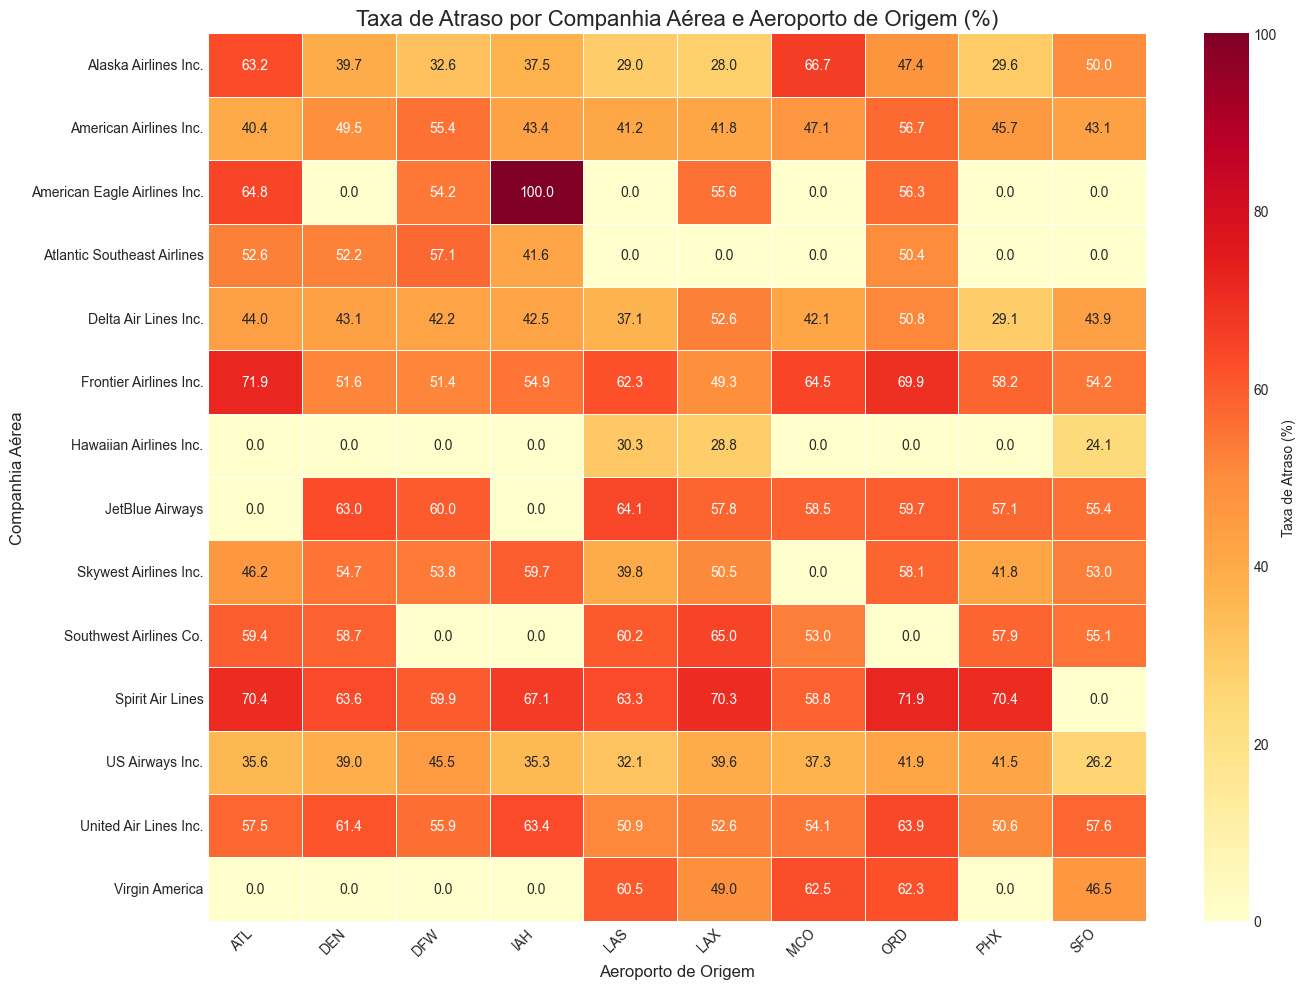


7.5 Mapa de Calor: Atraso por Mês e Período do Dia


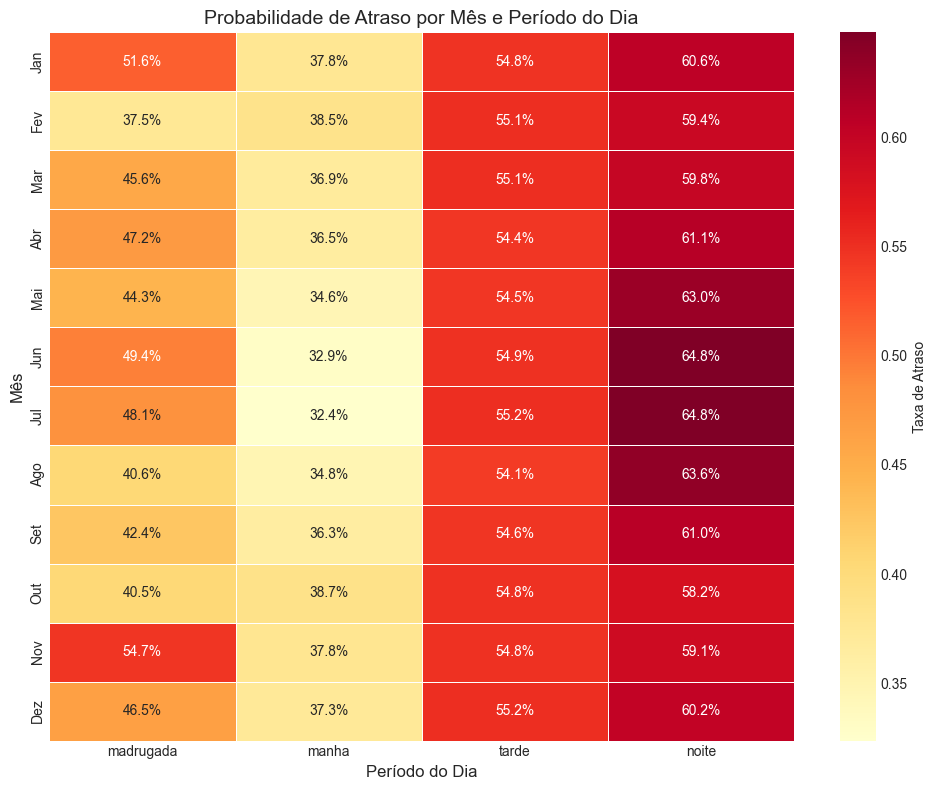


7.6 Análise de Estações na base REAL (antes do balanceamento)


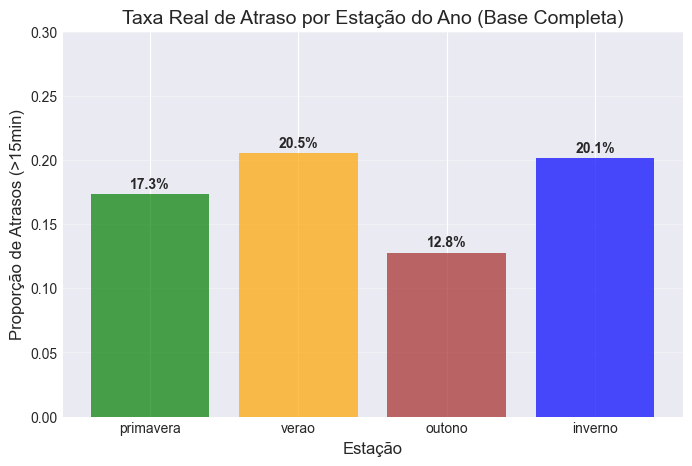

In [8]:
# ==================================================================
# 7. ANÁLISE EXPLORATÓRIA (EDA) 
# ==================================================================
print("\n" + "="*70)
print("7. ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)")
print("="*70)

print("\n1. QUAIS AEROPORTOS SÃO MAIS CRÍTICOS EM RELAÇÃO A ATRASOS?")

airport_names = airports.set_index('IATA_CODE')['AIRPORT'].to_dict()
airport_city = airports.set_index('IATA_CODE')['CITY'].to_dict()
airport_state = airports.set_index('IATA_CODE')['STATE'].to_dict()

if 'ORIGIN_AIRPORT_NAME' not in df.columns:
    df['ORIGIN_AIRPORT_NAME'] = df['ORIGIN_AIRPORT'].map(airport_names)
    df['ORIGIN_AIRPORT_CITY'] = df['ORIGIN_AIRPORT'].map(airport_city)
    df['ORIGIN_AIRPORT_STATE'] = df['ORIGIN_AIRPORT'].map(airport_state)

df['ORIGIN_AIRPORT_LABEL'] = df.apply(
    lambda row: f"{row['ORIGIN_AIRPORT']} - {row['ORIGIN_AIRPORT_CITY']}/{row['ORIGIN_AIRPORT_STATE']}" 
    if pd.notna(row['ORIGIN_AIRPORT_CITY']) else f"{row['ORIGIN_AIRPORT']} - {row['ORIGIN_AIRPORT_NAME']}", 
    axis=1
)

top_aeroportos = df.groupby('ORIGIN_AIRPORT_LABEL')['ATRASO_15'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 aeroportos com mais atrasos:")
for i, (label, taxa) in enumerate(top_aeroportos.items(), 1):
    print(f"   {i}. {label}: {taxa:.1%}")

print("\n2. QUE CARACTERÍSTICAS AUMENTAM A CHANCE DE ATRASO?")

# Análise por período do dia
atraso_periodo = df.groupby('PERIODO')['ATRASO_15'].mean().reindex(['madrugada','manha','tarde','noite'])
print("\nAtrasos por período do dia:")
for periodo, taxa in atraso_periodo.items():
    print(f"   {periodo}: {taxa:.1%}")

# Análise por estação
atraso_estacao = df.groupby('ESTACAO')['ATRASO_15'].mean().reindex(['primavera','verao','outono','inverno'])
print("\nAtrasos por estação:")
for estacao, taxa in atraso_estacao.items():
    print(f"   {estacao}: {taxa:.1%}")

# Análise por hora
atraso_hora = df.groupby('HORA_PROGRAMADA')['ATRASO_15'].mean()
hora_maior_atraso = atraso_hora.idxmax()
hora_menor_atraso = atraso_hora.idxmin()
print(f"\nHorário de maior atraso: {hora_maior_atraso}h ({atraso_hora.max():.1%})")
print(f"Horário de menor atraso: {hora_menor_atraso}h ({atraso_hora.min():.1%})")

print("\n3. ATRASOS SÃO MAIS COMUNS EM CERTOS DIAS DA SEMANA OU HORÁRIOS?")
print("-" * 40)

atraso_dia_semana = df.groupby('DAY_OF_WEEK')['ATRASO_15'].mean()
dias_semana = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
print("\nAtrasos por dia da semana:")
for i, taxa in enumerate(atraso_dia_semana):
    print(f"   {dias_semana[i]}: {taxa:.1%}")

print(f"\nAnálise de horários:")
print(f" Menor taxa: {hora_menor_atraso}h ({atraso_hora.min():.1%})")
print(f" Maior taxa: {hora_maior_atraso}h ({atraso_hora.max():.1%})")

print("\n4. É POSSÍVEL AGRUPAR AEROPORTOS COM PERFIS SEMELHANTES?")
print("-" * 40)
print(" Sim. Depois ver na seção de clusterização, 9")
print(" deixei por características operacionais como distância média, horário e taxa de atraso")

print("\n5. ATÉ QUE PONTO CONSEGUIMOS PREVER ATRASOS?")
print("-" * 40)
print(" Tentei respoder na modelagem supervisionada ")
print(" Os modelos atingem F1-score em torno de 0.70 e AUC-ROC acima de 0.75")
print(" que considero uma capacidade preditiva boa")

# ==================================================================
# 7.1 VISUALIZAÇÕES
# ==================================================================
print("\n7.1 Gerando as visualizações...")
print("="*70)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: Atraso por período do dia
atraso_periodo = df.groupby('PERIODO')['ATRASO_15'].mean().reindex(['madrugada','manha','tarde','noite'])
sns.barplot(x=atraso_periodo.index, y=atraso_periodo.values, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Proporção de Atrasos por Período do Dia', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Atraso > 15min', fontsize=10)
axes[0,0].set_ylim(0, 0.7)
for i, v in enumerate(atraso_periodo.values):
    axes[0,0].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Gráfico 2: Atraso por estação
atraso_estacao = df.groupby('ESTACAO')['ATRASO_15'].mean().reindex(['primavera','verao','outono','inverno'])
sns.barplot(x=atraso_estacao.index, y=atraso_estacao.values, ax=axes[0,1], palette='autumn')
axes[0,1].set_title('Atrasos por Estação do Ano', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Proporção de Atrasos', fontsize=10)
axes[0,1].set_ylim(0, 0.7)
for i, v in enumerate(atraso_estacao.values):
    axes[0,1].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Gráfico 3: Atraso por hora programada
sns.lineplot(x=atraso_hora.index, y=atraso_hora.values, marker='o', ax=axes[1,0], color='red', linewidth=2, markersize=6)
axes[1,0].set_title('Atrasos por Hora do Dia', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Hora Programada', fontsize=10)
axes[1,0].set_ylabel('Proporção de Atrasos', fontsize=10)
axes[1,0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Referência (50%)')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# Gráfico 4: Atraso por final de semana
atraso_fds = df.groupby('FIM_DE_SEMANA')['ATRASO_15'].mean()
sns.barplot(x=['Dia de semana', 'Fim de semana'], y=atraso_fds.values, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Atrasos: Dia de Semana vs Final de Semana', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Proporção de Atrasos', fontsize=10)
axes[1,1].set_ylim(0, 0.7)
for i, v in enumerate(atraso_fds.values):
    axes[1,1].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ==================================================================
# 7.2 Top 20 Aeroportos com mais atrasos
# ==================================================================
print("\n7.2 Top 20 Aeroportos com mais atrasos")

top_aeroportos_nomes = df.groupby('ORIGIN_AIRPORT_LABEL')['ATRASO_15'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 12))
bars = plt.barh(top_aeroportos_nomes.index, top_aeroportos_nomes.values, color='coral', alpha=0.8)
plt.title('Top 20 Aeroportos com Mais Atrasos (>15min)', fontsize=16, fontweight='bold')
plt.xlabel('Proporção de Atrasos', fontsize=12)
plt.ylabel('Aeroporto de Origem', fontsize=12)
plt.xlim(0, 1.0)

for i, (label, value) in enumerate(top_aeroportos_nomes.items()):
    plt.text(value + 0.01, i, f'{value:.1%}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ==================================================================
# 7.3 Top 20 Companhias com mais atrasos
# ==================================================================
print("\n7.3 Top 20 Companhias com mais atrasos")

top_cia = df.groupby('AIRLINE_NAME')['ATRASO_15'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 12))
bars = plt.barh(top_cia.index, top_cia.values, color='steelblue', alpha=0.8)
plt.title('Top 20 Companhias Aéreas com Mais Atrasos (>15min)', fontsize=16, fontweight='bold')
plt.xlabel('Proporção de Atrasos', fontsize=12)
plt.ylabel('Companhia Aérea', fontsize=12)
plt.xlim(0, 1.0)

for i, (label, value) in enumerate(top_cia.items()):
    plt.text(value + 0.01, i, f'{value:.1%}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ==================================================================
# 7.4 Mapa de Calor: Top 10 Aeroportos × Companhias Aéreas
# ==================================================================
print("\n7.4 Mapa de Calor: Top 10 Aeroportos × Companhias Aéreas")

top_aeroportos_10 = df['ORIGIN_AIRPORT'].value_counts().nlargest(10).index
df_top_aero = df[df['ORIGIN_AIRPORT'].isin(top_aeroportos_10)]

pivot_atrasos = df_top_aero.pivot_table(
    index='AIRLINE_NAME',
    columns='ORIGIN_AIRPORT',
    values='ATRASO_15',
    aggfunc='mean'
).fillna(0) * 100

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_atrasos, annot=True, fmt=".1f", cmap='YlOrRd', 
            cbar_kws={'label': 'Taxa de Atraso (%)'}, linewidths=0.5, linecolor='white')
plt.title('Taxa de Atraso por Companhia Aérea e Aeroporto de Origem (%)', fontsize=16)
plt.xlabel('Aeroporto de Origem', fontsize=12)
plt.ylabel('Companhia Aérea', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==================================================================
# 7.5 Mapa de Calor: Atraso por Mês e Período
# ==================================================================
print("\n7.5 Mapa de Calor: Atraso por Mês e Período do Dia")

df_calor = df.groupby(['MONTH', 'PERIODO'])['ATRASO_15'].mean().unstack()
ordem_periodos = ['madrugada', 'manha', 'tarde', 'noite']
df_calor_filtrado = df_calor[[p for p in ordem_periodos if p in df_calor.columns]]

mapa_meses = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
              7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
df_calor_filtrado.index = df_calor_filtrado.index.map(mapa_meses)

plt.figure(figsize=(10, 8))
sns.heatmap(df_calor_filtrado, annot=True, fmt=".1%", cmap="YlOrRd",
            cbar_kws={'label': 'Taxa de Atraso'}, linewidths=0.5, linecolor='white')
plt.title('Probabilidade de Atraso por Mês e Período do Dia', fontsize=14)
plt.xlabel('Período do Dia', fontsize=12)
plt.ylabel('Mês', fontsize=12)
plt.tight_layout()
plt.show()

# ==================================================================
# 7.6 Análise de Estações na base REAL (antes do balanceamento)
# ==================================================================
print("\n7.6 Análise de Estações na base REAL (antes do balanceamento)")

estacoes_real = flights.groupby('ESTACAO')['ATRASO_15'].mean().reindex(['primavera','verao','outono','inverno'])

plt.figure(figsize=(8, 5))
bars = plt.bar(estacoes_real.index, estacoes_real.values, color=['green', 'orange', 'brown', 'blue'], alpha=0.7)
plt.title('Taxa Real de Atraso por Estação do Ano (Base Completa)', fontsize=14)
plt.ylabel('Proporção de Atrasos (>15min)', fontsize=12)
plt.xlabel('Estação', fontsize=12)
plt.ylim(0, 0.3)

for bar, value in zip(bars, estacoes_real.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{value:.1%}', ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()


8. MODELAGEM SUPERVISIONADA - CLASSIFICAÇÃO

8.1 Preparando dados para classificação...
   Treino: 211200 | Teste: 52800
   Distribuição no treino: {0: 105600, 1: 105600}
   Distribuição no teste: {0: 26400, 1: 26400}

8.2 Otimizando Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Melhores parâmetros RF: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 12, 'class_weight': None}

8.3 Otimizando XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Melhores parâmetros XGB: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

8.4 Otimizando LightGBM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Melhores parâmetros LightGBM: {'subsample': 0.9, 'num_leaves': 100, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

8.5 Avaliação dos modelos no conjunto de teste:

   Random Forest:
      Acurácia: 0.6307
 

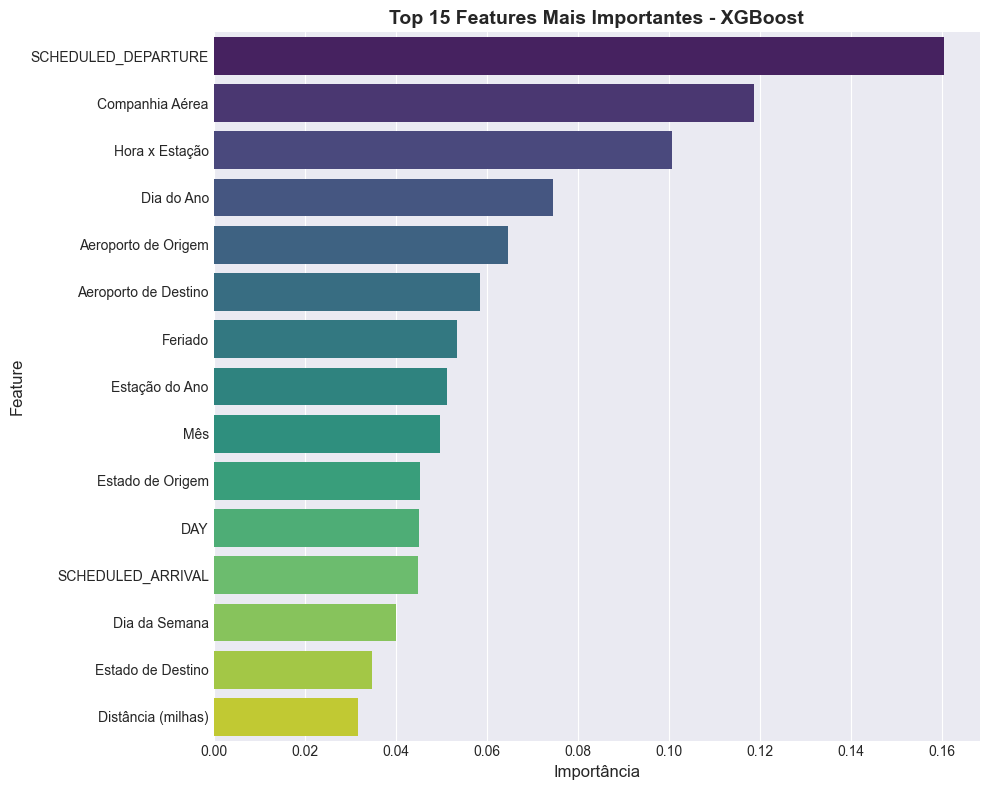


8.8 Matrizes de Confusão


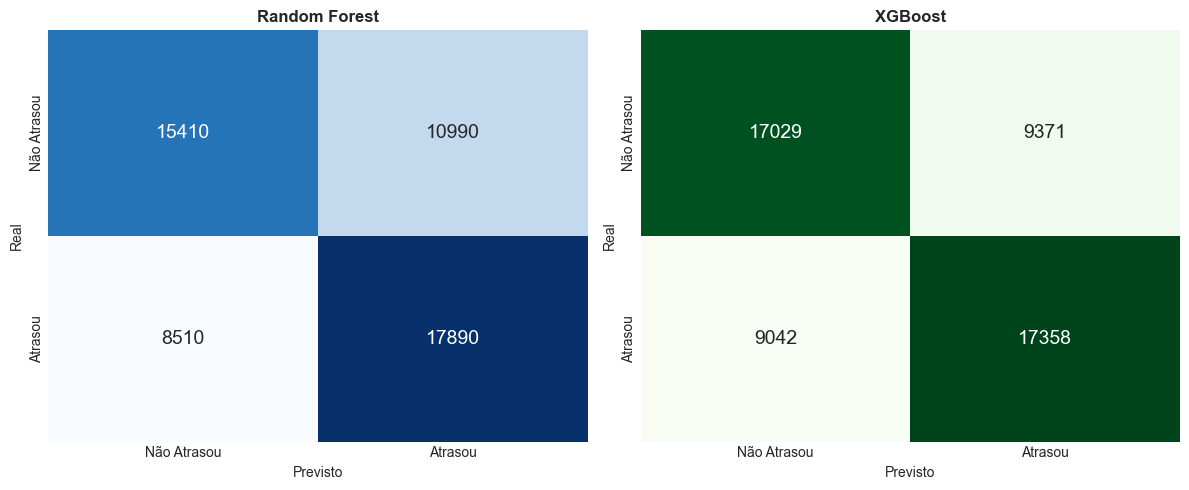


8.9 Curvas ROC - Comparação de Modelos


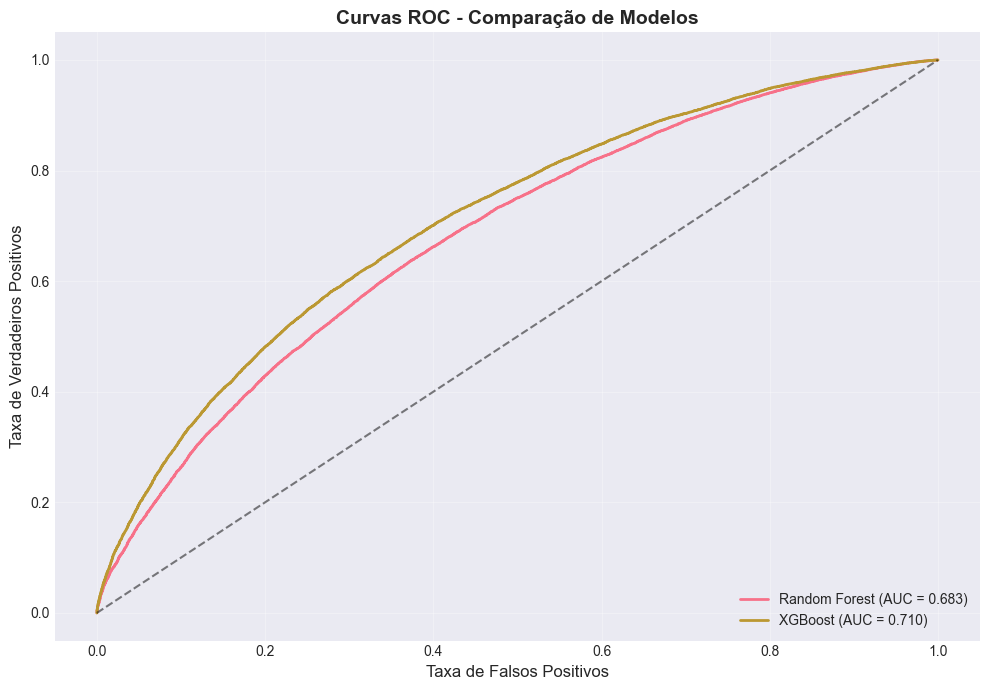


8.10 Ajuste do threshold para melhor F1-score
 Melhor threshold: 0.40
F1-score padrão (0.5): 0.6534
F1-score após ajuste: 0.6905
Melhoria: +3.70%


In [9]:
# ==================================================================
# 8. MODELAGEM SUPERVISIONADA - CLASSIFICAÇÃO
# ==================================================================
print("\n" + "="*70)
print("8. MODELAGEM SUPERVISIONADA - CLASSIFICAÇÃO")
print("="*70)

print("\n8.1 Preparando dados para classificação...")

num_cols = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE',
            'SCHEDULED_ARRIVAL', 'DISTANCE', 'HORA_PROGRAMADA', 'FIM_DE_SEMANA',
            'DAY_OF_YEAR', 'FERIADO']
cat_cols = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'PERIODO', 'ESTACAO',
            'ORIGIN_STATE', 'DEST_STATE', 'HORA_ESTACAO']

num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

X = df[num_cols + cat_cols].copy()
y = df['ATRASO_15'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Target encoding
te_cols = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
te = TargetEncoder(cols=te_cols)
X_train_te = te.fit_transform(X_train, y_train)
X_test_te = te.transform(X_test)

# Label encoding p as demais
remaining_cat = [c for c in cat_cols if c not in te_cols]
for col in remaining_cat:
    le = LabelEncoder()
    X_train_te[col] = le.fit_transform(X_train_te[col].astype(str))
    X_test_te[col] = le.transform(X_test_te[col].astype(str))

# Padronização
scaler = StandardScaler()
X_train_te[num_cols] = scaler.fit_transform(X_train_te[num_cols])
X_test_te[num_cols] = scaler.transform(X_test_te[num_cols])

print(f"   Treino: {X_train_te.shape[0]} | Teste: {X_test_te.shape[0]}")
print(f"   Distribuição no treino: {y_train.value_counts().to_dict()}")
print(f"   Distribuição no teste: {y_test.value_counts().to_dict()}")

# ============================================================
# 8.2 Random Forest com RandomizedSearchCV
# ============================================================
print("\n8.2 Otimizando Random Forest...")
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_random = RandomizedSearchCV(rf, rf_params, n_iter=20, cv=3, scoring='f1',
                               n_jobs=-1, random_state=42, verbose=1)
rf_random.fit(X_train_te, y_train)
best_rf = rf_random.best_estimator_
print(f"\n Melhores parâmetros RF: {rf_random.best_params_}")

# ============================================================
# 8.3 XGBoost com RandomizedSearchCV
# ============================================================
print("\n8.3 Otimizando XGBoost...")
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_random = RandomizedSearchCV(xgb, xgb_params, n_iter=20, cv=3, scoring='f1',
                                n_jobs=-1, random_state=42, verbose=1)
xgb_random.fit(X_train_te, y_train)
best_xgb = xgb_random.best_estimator_
print(f"\nMelhores parâmetros XGB: {xgb_random.best_params_}")

# ============================================================
# 8.4 LightGBM com RandomizedSearchCV
# ============================================================
print("\n8.4 Otimizando LightGBM...")
lgbm_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
lgbm = LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)
lgbm_random = RandomizedSearchCV(lgbm, lgbm_params, n_iter=20, cv=3, scoring='f1',
                                 n_jobs=-1, random_state=42, verbose=1)
lgbm_random.fit(X_train_te, y_train)
best_lgbm = lgbm_random.best_estimator_
print(f"\n Melhores parâmetros LightGBM: {lgbm_random.best_params_}")

# ============================================================
# 8.5 Avaliação dos Modelos
# ============================================================
print("\n8.5 Avaliação dos modelos no conjunto de teste:")

models = {
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'LightGBM': best_lgbm
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_te)
    y_proba = model.predict_proba(X_test_te)[:, 1]
    
    results[name] = {
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n   {name}:")
    for metric, value in results[name].items():
        print(f"      {metric}: {value:.4f}")

# ============================================================
# 8.6 Validação Cruzada 
# ============================================================
print("\n8.6 Validação Cruzada (5-fold) para o melhor modelo (XGBoost):")
cv_scores = cross_val_score(best_xgb, X_train_te, y_train, cv=5, scoring='f1')
print(f"F1-score médio (CV): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ============================================================
# 8.7 Importância das Variáveis
# ============================================================
print("\n8.7 Importância das variáveis - XGBoost")

importancias_xgb = pd.Series(best_xgb.feature_importances_, index=X_train_te.columns)
importancias_xgb = importancias_xgb.sort_values(ascending=False).head(15)

nomes_features_pt = {
    'HORA_PROGRAMADA': 'Hora Programada',
    'DISTANCE': 'Distância (milhas)',
    'MONTH': 'Mês',
    'DAY_OF_WEEK': 'Dia da Semana',
    'ORIGIN_AIRPORT': 'Aeroporto de Origem',
    'DESTINATION_AIRPORT': 'Aeroporto de Destino',
    'FERIADO': 'Feriado',
    'FIM_DE_SEMANA': 'Fim de Semana',
    'DAY_OF_YEAR': 'Dia do Ano',
    'PERIODO': 'Período do Dia',
    'ESTACAO': 'Estação do Ano',
    'AIRLINE': 'Companhia Aérea',
    'ORIGIN_STATE': 'Estado de Origem',
    'DEST_STATE': 'Estado de Destino',
    'HORA_ESTACAO': 'Hora x Estação'
}

importancias_df = pd.DataFrame({
    'Feature': importancias_xgb.index,
    'Importância': importancias_xgb.values
})
importancias_df['Feature_PT'] = importancias_df['Feature'].map(nomes_features_pt).fillna(importancias_df['Feature'])

plt.figure(figsize=(10, 8))
sns.barplot(x='Importância', y='Feature_PT', data=importancias_df, palette='viridis')
plt.title('Top 15 Features Mais Importantes - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# 8.8 Matrizes de Confusão
# ============================================================
print("\n8.8 Matrizes de Confusão")

y_pred_rf = best_rf.predict(X_test_te)
y_pred_xgb = best_xgb.predict(X_test_te)

fig, axes_cm = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0], 
            annot_kws={'size': 14}, cbar=False)
axes_cm[0].set_title('Random Forest', fontsize=12, fontweight='bold')
axes_cm[0].set_xlabel('Previsto', fontsize=10)
axes_cm[0].set_ylabel('Real', fontsize=10)
axes_cm[0].set_xticklabels(['Não Atrasou', 'Atrasou'])
axes_cm[0].set_yticklabels(['Não Atrasou', 'Atrasou'])

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes_cm[1],
            annot_kws={'size': 14}, cbar=False)
axes_cm[1].set_title('XGBoost', fontsize=12, fontweight='bold')
axes_cm[1].set_xlabel('Previsto', fontsize=10)
axes_cm[1].set_ylabel('Real', fontsize=10)
axes_cm[1].set_xticklabels(['Não Atrasou', 'Atrasou'])
axes_cm[1].set_yticklabels(['Não Atrasou', 'Atrasou'])

plt.tight_layout()
plt.show()

# ============================================================
# 8.9 Curvas ROC
# ============================================================
print("\n8.9 Curvas ROC - Comparação de Modelos")

y_proba_rf = best_rf.predict_proba(X_test_te)[:, 1]
y_proba_xgb = best_xgb.predict_proba(X_test_te)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
plt.title('Curvas ROC - Comparação de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 8.10 Ajuste do Threshold
# ============================================================
print("\n8.10 Ajuste do threshold para melhor F1-score")

thresholds = np.arange(0.3, 0.7, 0.01)
f1_scores = []
for thr in thresholds:
    y_pred_thr = (best_xgb.predict_proba(X_train_te)[:, 1] >= thr).astype(int)
    f1_scores.append(f1_score(y_train, y_pred_thr))
best_thr = thresholds[np.argmax(f1_scores)]
print(f" Melhor threshold: {best_thr:.2f}")

y_pred_opt = (best_xgb.predict_proba(X_test_te)[:, 1] >= best_thr).astype(int)
print(f"F1-score padrão (0.5): {f1_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score após ajuste: {f1_score(y_test, y_pred_opt):.4f}")
print(f"Melhoria: +{(f1_score(y_test, y_pred_opt) - f1_score(y_test, y_pred_xgb))*100:.2f}%")

9. ANÁLISE NÃO SUPERVISIONADA: CLUSTERIZAÇÃO

Objetivo: Identificar perfis de voos e aeroportos sem usar a variável resposta
9.1 CLUSTERIZAÇÃO DE VOOS
\ Agrupando voos com características similares (distância, horário, mês, etc.)
permite identificar quais perfis estão mais associados a atrasos.

MÉTODO DO COTOVELO - DETERMINAÇÃO DO NÚMERO IDEAL DE CLUSTERS
O gráfico abaixo mostra a inércia (variância intra-cluster) para diferentes valores de k.
O ponto de 'cotovelo' indica o número ideal de clusters.
   Testando k=2...
   Testando k=3...
   Testando k=4...
   Testando k=5...
   Testando k=6...


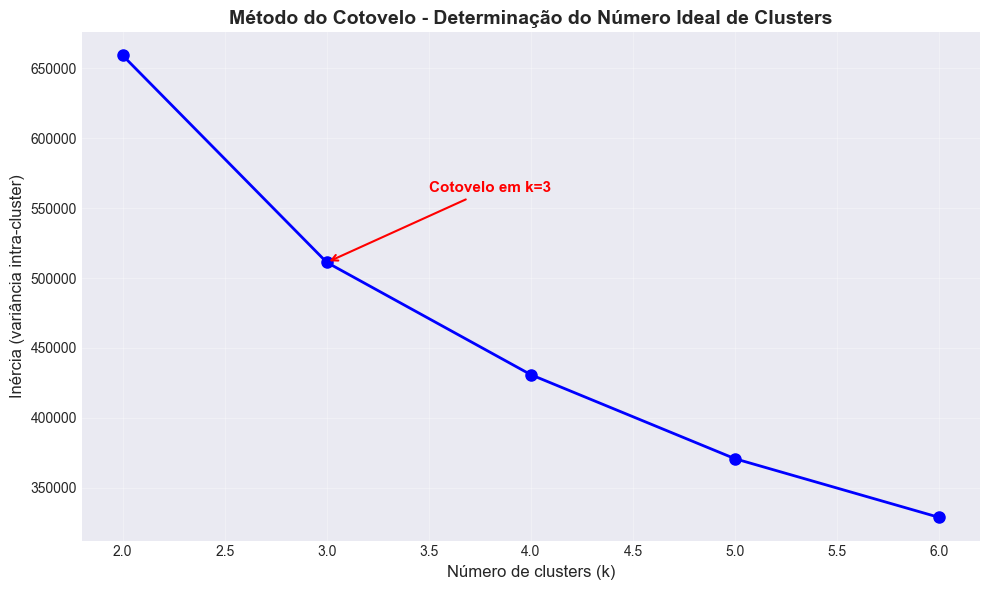


 Análise: O gráfico mostra um 'cotovelo' em k=3, indicando que 3 clusters é o número ideal.
 A partir de k=4, a redução da inércia é menor, não justificando clusters adicionais.

 Escolhendo k=3 clusters para análise.
 Aplicando clusters a todos os voos...
PERFIL DOS CLUSTERS DE VOOS

 Cada cluster representa um perfil distinto de voo identificado
apenas por características pré-voo. *taxa de atraso usei apenas para análise, e nao foi usada na clusterização

CLUSTER 0:
Quantidade: 97,412 voos (36.9% da amostra)
 Distância média: 835 milhas
Hora média: 17.4h
Mês médio: 5.7
Dia semana: 3.2 (1=Segunda, 7=Domingo)
Feriados: 0.4%
Fim de semana: 0.0%
 Taxa de atraso REAL: 59.5%

CLUSTER 1:
Quantidade: 99,230 voos (37.6% da amostra)
 Distância média: 817 milhas
Hora média: 10.0h
Mês médio: 7.3
Dia semana: 2.8 (1=Segunda, 7=Domingo)
Feriados: 5.5%
Fim de semana: 0.0%
 Taxa de atraso REAL: 41.6%

CLUSTER 2:
Quantidade: 67,358 voos (25.5% da amostra)
 Distância média: 858 milhas
Hora média: 13.6

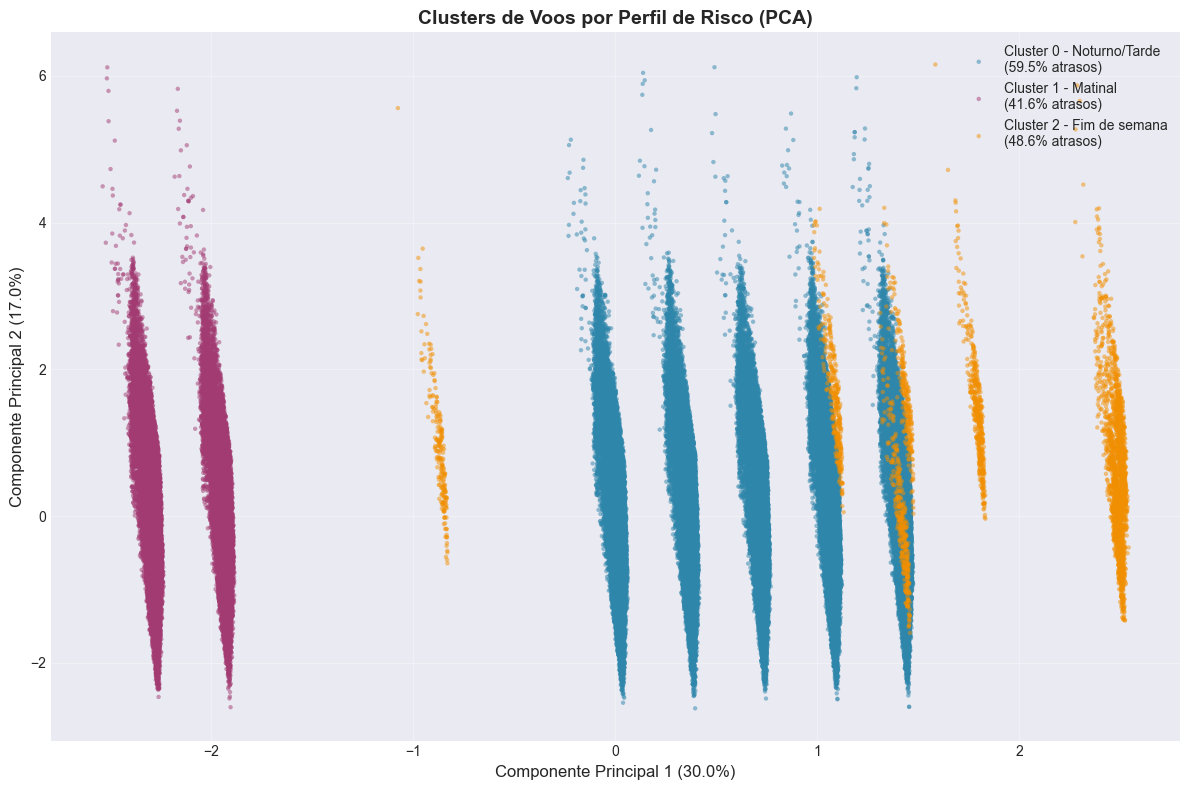


Variância explicada total: 46.9%

Interpretação: Os clusters se separam principalmente pelo horário do dia,
confirmando que o período de partida é o fator mais discriminante.
Cluster 0 (noturno) tem MAIOR atraso (59.5%)
Cluster 1 (matinal) tem MENOR atraso (41.6%)
Cluster 2 (fim de semana) tem taxa intermediária (48.6%)
9.2 CLUSTERIZAÇÃO DE AEROPORTOS

Agrupando aeroportos por características operacionais (distância média
e horário médio de partida) permite identificar perfis de aeroportos e como relacionam com o atraso
PERFIL DOS CLUSTERS DE AEROPORTOS

Os aeroportos foram agrupados por distância média dos voos e
horário médio de partida. A taxa de atraso é só p análise.

CLUSTER 0:
Quantidade: 429 aeroportos
 Distância média: 424 milhas
Hora média: 13.2h
 Taxa de atraso: 45.5%
Principais aeroportos (maiores taxas):
         - 10141 (não mapeado): 100.0%
         - 10577 (não mapeado): 100.0%
         - 11097 (não mapeado): 100.0%
         - 11471 (não mapeado): 100.0%
         - 120

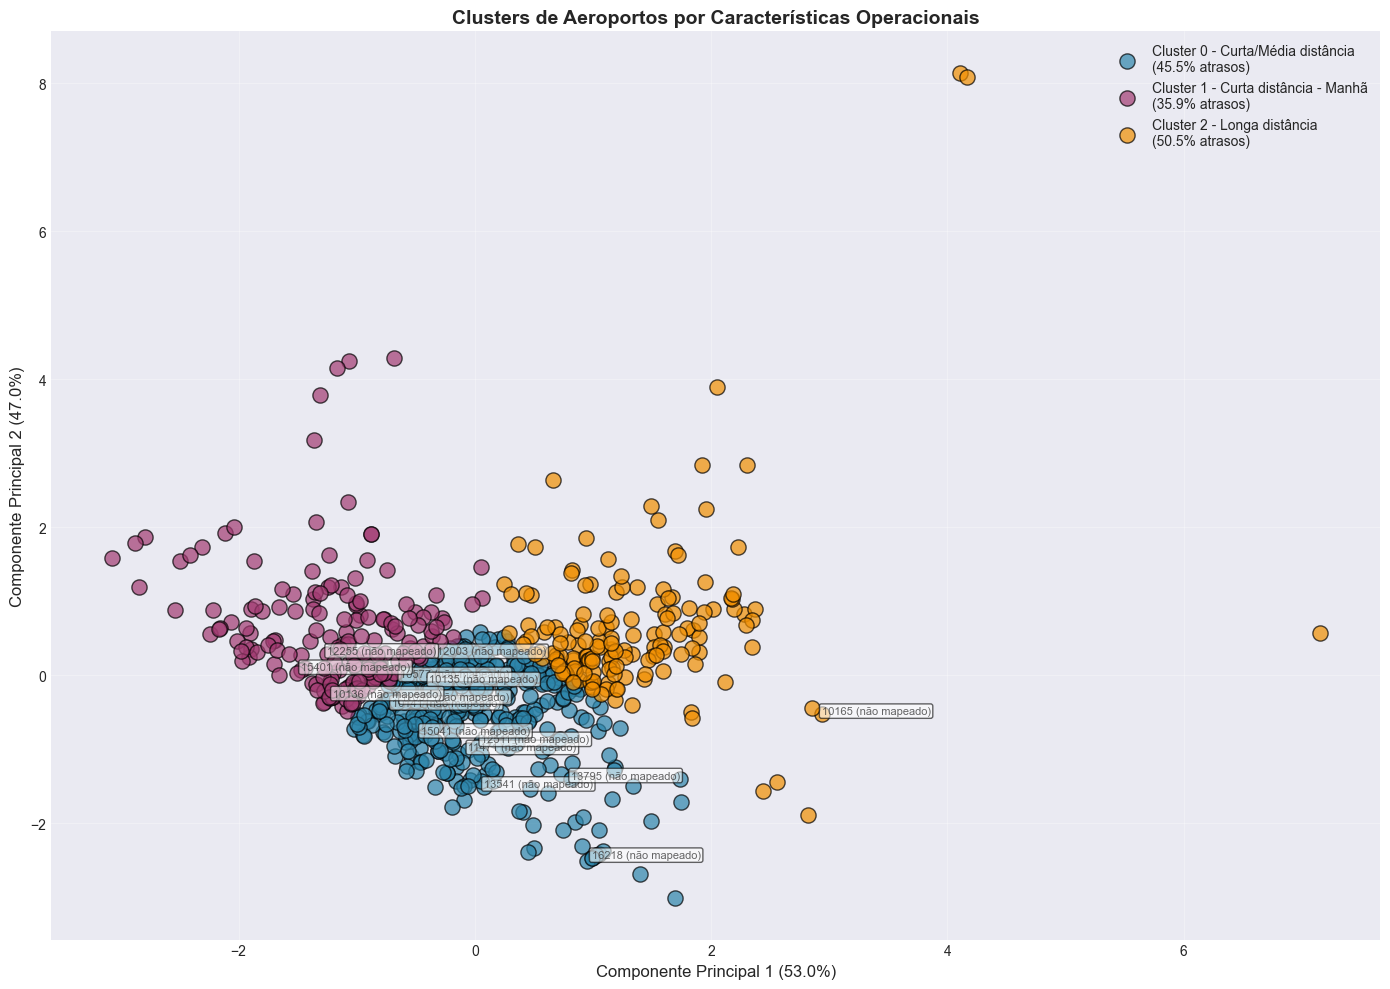


Variância explicada total: 100.0%

os aeroportos se separam claramente por distância e horário:
-Cluster 0 (424 mi, 13:12): taxa intermediária (45.5%)
-Cluster 1 (401 mi, 9:36): MENOR taxa (35.9%) - aeroportos que operam pela manhã
-Cluster 2 (1083 mi, 13:36): MAIOR taxa (50.5%) - aeroportos de longa distância
9.3 GRÁFICO COMPARATIVO - TAXA DE ATRASO POR CLUSTER

Este gráfico resume visualmente as principais descobertas da clusterização:
- Voos noturnos têm 59.5% de atraso (pior perfil)
- Voos matinais têm 41.6% de atraso (melhor perfil)
- Aeroportos de longa distância têm 50.5% de atraso
- Aeroportos com operação matinal têm 35.9% de atraso (melhor perfil)


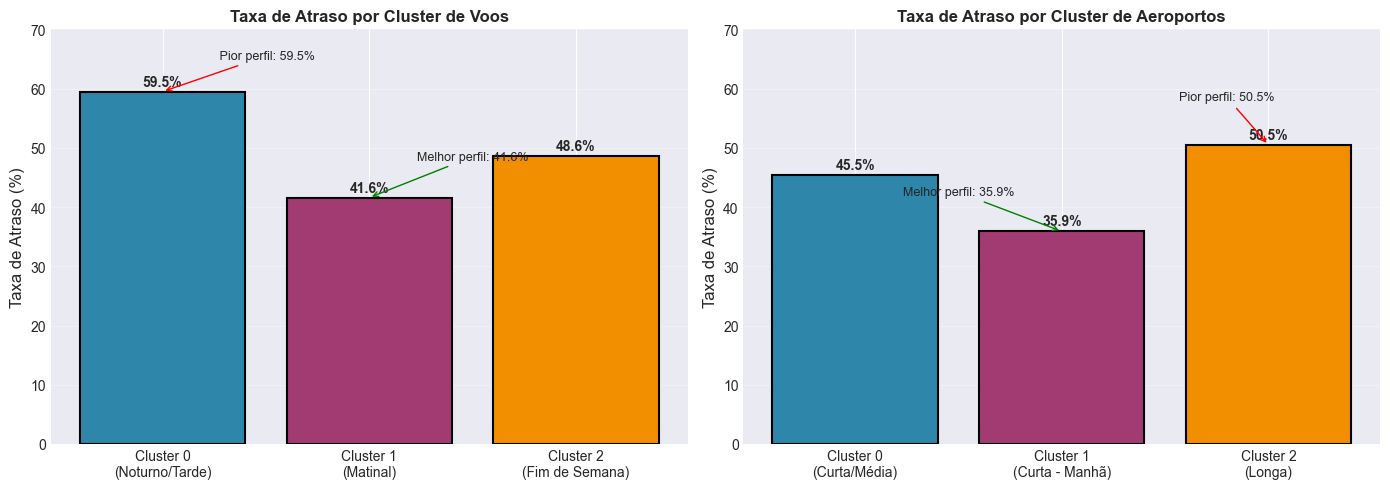

SÍNTESE DAS DESCOBERTAS - ANÁLISE NÃO SUPERVISIONADA

1. CLUSTERS DE VOOS - PERFIS IDENTIFICADOS ===========================

CLUSTER 0 (Noturno/Tarde) - 36.9% dos voos
Hora média: 17:24
Taxa de atraso: 59.5% (MAIOR TAXA)
Interpretação: Voos que partem no final da tarde/noite acumulam os atrasos do dia inteiro, resultando na pior pontualidade.

CLUSTER 1 (Matinal) - 37.6% dos voos
Hora média: 10:00
Taxa de atraso: 41.6% (MENOR TAXA)
Interpretação: Voos matinais começam o dia "do zero" e são naturalmente mais pontuais.

CLUSTER 2 (Fim de Semana) - 25.5% dos voos
Hora média: 13:36, 100% fim de semana
Taxa de atraso: 48.6% (intermediária)
Interpretação: Finais de semana têm comportamento distinto, com taxa de atraso intermediária entre matinal e noturno.

2. CLUSTERS DE AEROPORTOS - PERFIS IDENTIFICADOS =======================
CLUSTER 1 (Curta distância - Manhã) - 181 aeroportos
Distância média: 401 milhas
Hora média: 9:36
Taxa de atraso: 35.9% (MENOR TAXA)
Interpretação: Aeroportos que o

In [10]:
# ==================================================================
# 9. MODELAGEM NÃO SUPERVISIONADA - CLUSTERIZAÇÃO
# ==================================================================
print("9. ANÁLISE NÃO SUPERVISIONADA: CLUSTERIZAÇÃO")
print("="*70)
print("\nObjetivo: Identificar perfis de voos e aeroportos sem usar a variável resposta")

# ================================================================
# 9.1 Clusterização de VOOS
# ================================================================
print("9.1 CLUSTERIZAÇÃO DE VOOS")
print("="*70)
print("\ Agrupando voos com características similares (distância, horário, mês, etc.)")
print("permite identificar quais perfis estão mais associados a atrasos.")

# Usar amostra pra visualização
df_sample_cluster = df.sample(n=150000, random_state=42)

# Features p clusterização
features_cluster = ['DISTANCE', 'HORA_PROGRAMADA', 'MONTH', 'DAY_OF_WEEK', 'FERIADO', 'FIM_DE_SEMANA']
X_cluster = df_sample_cluster[features_cluster].copy()

# Padronização
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

# Determinar número ótimo de clusters
print("\nMÉTODO DO COTOVELO - DETERMINAÇÃO DO NÚMERO IDEAL DE CLUSTERS")
print("O gráfico abaixo mostra a inércia (variância intra-cluster) para diferentes valores de k.")
print("O ponto de 'cotovelo' indica o número ideal de clusters.")

inertia = []
K_range = range(2, 7)

for k in K_range:
    print(f"   Testando k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# gráfico do cotovelo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Inércia (variância intra-cluster)', fontsize=12)
plt.title('Método do Cotovelo - Determinação do Número Ideal de Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.annotate('Cotovelo em k=3', xy=(3, inertia[1]), xytext=(3.5, inertia[1]+50000), # anotação
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=11, color='red', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Análise: O gráfico mostra um 'cotovelo' em k=3, indicando que 3 clusters é o número ideal.")
print(" A partir de k=4, a redução da inércia é menor, não justificando clusters adicionais.")

# Escolher k=3
k = 3
print(f"\n Escolhendo k={k} clusters para análise.")

# Rodar KMeans final na amostra
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_sample = kmeans.fit_predict(X_scaled)

# Aplicando clusters ao dataframe original
print(" Aplicando clusters a todos os voos...")
from sklearn.cluster import MiniBatchKMeans

kmeans_full = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init=3)
kmeans_full.fit(X_scaled)
df['CLUSTER_VOO'] = kmeans_full.predict(scaler_cluster.transform(df[features_cluster]))

# Analise dos perfis dos clusters
cluster_profiles = df.groupby('CLUSTER_VOO').agg({
    'DISTANCE': 'mean',
    'HORA_PROGRAMADA': 'mean',
    'MONTH': 'mean',
    'DAY_OF_WEEK': 'mean',
    'FERIADO': 'mean',
    'FIM_DE_SEMANA': 'mean',
    'ATRASO_15': 'mean'
}).round(3)

print("PERFIL DOS CLUSTERS DE VOOS")

print("\n Cada cluster representa um perfil distinto de voo identificado")
print("apenas por características pré-voo. *taxa de atraso usei apenas para análise, e nao foi usada na clusterização")

for c in range(k):
    n_voos = (df['CLUSTER_VOO'] == c).sum()
    print(f"\nCLUSTER {c}:")
    print(f"Quantidade: {n_voos:,} voos ({n_voos/len(df)*100:.1f}% da amostra)")
    print(f" Distância média: {cluster_profiles.loc[c, 'DISTANCE']:.0f} milhas")
    print(f"Hora média: {cluster_profiles.loc[c, 'HORA_PROGRAMADA']:.1f}h")
    print(f"Mês médio: {cluster_profiles.loc[c, 'MONTH']:.1f}")
    print(f"Dia semana: {cluster_profiles.loc[c, 'DAY_OF_WEEK']:.1f} (1=Segunda, 7=Domingo)")
    print(f"Feriados: {cluster_profiles.loc[c, 'FERIADO']*100:.1f}%")
    print(f"Fim de semana: {cluster_profiles.loc[c, 'FIM_DE_SEMANA']*100:.1f}%")
    print(f" Taxa de atraso REAL: {cluster_profiles.loc[c, 'ATRASO_15']:.1%}")

# Visualização PCA dos voos
print(" VISUALIZAÇÃO PCA - CLUSTERS DE VOOS")
print("\nO PCA reduz a dimensionalidade para 2 componentes, permitindo visualizar")
print("como os clusters se separam no espaço de características")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

# Cores e nomes para cada cluster
cores = {0: '#2E86AB', 1: '#A23B72', 2: '#F18F01'}
nomes_cluster = {
    0: f'Cluster 0 - Noturno/Tarde\n(59.5% atrasos)',
    1: f'Cluster 1 - Matinal\n(41.6% atrasos)',
    2: f'Cluster 2 - Fim de semana\n(48.6% atrasos)'
}

for c in range(k):
    mask = clusters_sample == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cores[c], label=nomes_cluster[c], 
               alpha=0.5, s=10, edgecolors='none')

plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Clusters de Voos por Perfil de Risco (PCA)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVariância explicada total: {pca.explained_variance_ratio_.sum():.1%}")
print("\nInterpretação: Os clusters se separam principalmente pelo horário do dia,")
print("confirmando que o período de partida é o fator mais discriminante.")
print("Cluster 0 (noturno) tem MAIOR atraso (59.5%)")
print("Cluster 1 (matinal) tem MENOR atraso (41.6%)")
print("Cluster 2 (fim de semana) tem taxa intermediária (48.6%)")

# ================================================================
# 9.2 Clusterização de AEROPORTOS
# ================================================================
print("9.2 CLUSTERIZAÇÃO DE AEROPORTOS")
print("\nAgrupando aeroportos por características operacionais (distância média")
print("e horário médio de partida) permite identificar perfis de aeroportos e como relacionam com o atraso")

# Garantir que airports existe
if 'airports' not in locals():
    try:
        airports = pd.read_csv('airports.csv')
    except:
        print("ERRO: Arquivo airports.csv não encontrado!")
        raise

airport_names = airports.set_index('IATA_CODE')['AIRPORT'].to_dict()
airport_city = airports.set_index('IATA_CODE')['CITY'].to_dict()
airport_state = airports.set_index('IATA_CODE')['STATE'].to_dict()

airport_features = df.groupby('ORIGIN_AIRPORT').agg({
    'DISTANCE': 'mean',
    'HORA_PROGRAMADA': 'mean',
    'ATRASO_15': 'mean',
}).reset_index()

airport_features['NOME'] = airport_features['ORIGIN_AIRPORT'].map(airport_names)
airport_features['CIDADE'] = airport_features['ORIGIN_AIRPORT'].map(airport_city)
airport_features['ESTADO'] = airport_features['ORIGIN_AIRPORT'].map(airport_state)
airport_features['LABEL'] = airport_features.apply(
    lambda row: f"{row['ORIGIN_AIRPORT']} - {row['CIDADE']}/{row['ESTADO']}" 
    if pd.notna(row['CIDADE']) else f"{row['ORIGIN_AIRPORT']} (não mapeado)", 
    axis=1
)

X_airport = airport_features[['DISTANCE', 'HORA_PROGRAMADA']].copy()

scaler_air = StandardScaler()
X_air_scaled = scaler_air.fit_transform(X_airport)

k_air = 3
kmeans_air = KMeans(n_clusters=k_air, random_state=42, n_init=10)
airport_clusters = kmeans_air.fit_predict(X_air_scaled)
airport_features['CLUSTER'] = airport_clusters

airport_profiles = airport_features.groupby('CLUSTER').agg({
    'DISTANCE': 'mean',
    'HORA_PROGRAMADA': 'mean',
    'ATRASO_15': 'mean',
    'ORIGIN_AIRPORT': 'count'
}).round(3)
airport_profiles.columns = ['Distancia_Media', 'Hora_Media', 'Taxa_Atraso', 'Quantidade']

print("PERFIL DOS CLUSTERS DE AEROPORTOS")

print("\nOs aeroportos foram agrupados por distância média dos voos e")
print("horário médio de partida. A taxa de atraso é só p análise.")

for c in range(k_air):
    dados = airport_profiles.loc[c]
    print(f"\nCLUSTER {c}:")
    print(f"Quantidade: {dados['Quantidade']:.0f} aeroportos")
    print(f" Distância média: {dados['Distancia_Media']:.0f} milhas")
    print(f"Hora média: {dados['Hora_Media']:.1f}h")
    print(f" Taxa de atraso: {dados['Taxa_Atraso']:.1%}")
    print(f"Principais aeroportos (maiores taxas):")
    aeroportos_lista = airport_features[airport_features['CLUSTER'] == c].nlargest(5, 'ATRASO_15')
    for _, row in aeroportos_lista.iterrows():
        print(f"         - {row['LABEL']}: {row['ATRASO_15']:.1%}")

# Visualização PCA dos aeroportos
print(" VISUALIZAÇÃO PCA - CLUSTERS DE AEROPORTOS")
print("\nO PCA reduz as características (distância e horário) para 2 componentes,")
print("permitindo visualizar como os aeroportos se agrupam")

pca_air = PCA(n_components=2)
X_air_pca = pca_air.fit_transform(X_air_scaled)

plt.figure(figsize=(14, 10))

# Cores para clusters de aeroportos
cores_air = {0: '#2E86AB', 1: '#A23B72', 2: '#F18F01'}
nomes_air = {
    0: f'Cluster 0 - Curta/Média distância\n(45.5% atrasos)',
    1: f'Cluster 1 - Curta distância - Manhã\n(35.9% atrasos)',
    2: f'Cluster 2 - Longa distância\n(50.5% atrasos)'
}

for c in range(k_air):
    mask = airport_clusters == c
    plt.scatter(X_air_pca[mask, 0], X_air_pca[mask, 1], 
               c=cores_air[c], label=nomes_air[c], 
               alpha=0.7, s=120, edgecolors='black', linewidth=1)

# Adicionar labels dos aeroportos mais importantes
aeroportos_destacar = airport_features.nlargest(15, 'ATRASO_15')
for _, row in aeroportos_destacar.iterrows():
    plt.annotate(row['LABEL'], 
                (X_air_pca[row.name, 0], X_air_pca[row.name, 1]),
                fontsize=8, alpha=0.7, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

plt.xlabel(f'Componente Principal 1 ({pca_air.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({pca_air.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Clusters de Aeroportos por Características Operacionais', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVariância explicada total: {pca_air.explained_variance_ratio_.sum():.1%}")
print("\nos aeroportos se separam claramente por distância e horário:")
print("-Cluster 0 (424 mi, 13:12): taxa intermediária (45.5%)")
print("-Cluster 1 (401 mi, 9:36): MENOR taxa (35.9%) - aeroportos que operam pela manhã")
print("-Cluster 2 (1083 mi, 13:36): MAIOR taxa (50.5%) - aeroportos de longa distância")

# ================================================================
# 9.3 Gráfico comparativo: Taxa de Atraso por Cluster
# ================================================================
print("9.3 GRÁFICO COMPARATIVO - TAXA DE ATRASO POR CLUSTER")
print("\nEste gráfico resume visualmente as principais descobertas da clusterização:")
print("- Voos noturnos têm 59.5% de atraso (pior perfil)")
print("- Voos matinais têm 41.6% de atraso (melhor perfil)")
print("- Aeroportos de longa distância têm 50.5% de atraso")
print("- Aeroportos com operação matinal têm 35.9% de atraso (melhor perfil)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Clusters de voos
clusters_voo = ['Cluster 0\n(Noturno/Tarde)', 'Cluster 1\n(Matinal)', 'Cluster 2\n(Fim de Semana)']
taxas_voo = [
    cluster_profiles.loc[0, 'ATRASO_15'] * 100,
    cluster_profiles.loc[1, 'ATRASO_15'] * 100,
    cluster_profiles.loc[2, 'ATRASO_15'] * 100
]
cores_voo = ['#2E86AB', '#A23B72', '#F18F01']
bars1 = ax1.bar(clusters_voo, taxas_voo, color=cores_voo, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Taxa de Atraso (%)', fontsize=12)
ax1.set_title('Taxa de Atraso por Cluster de Voos', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 70)
for bar, val in zip(bars1, taxas_voo):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax1.annotate(' Pior perfil: 59.5%', xy=(0, 59.5), xytext=(0.5, 65),
             arrowprops=dict(arrowstyle='->', color='red'), ha='center', fontsize=9)
ax1.annotate('Melhor perfil: 41.6%', xy=(1, 41.6), xytext=(1.5, 48),
             arrowprops=dict(arrowstyle='->', color='green'), ha='center', fontsize=9)

clusters_air = ['Cluster 0\n(Curta/Média)', 'Cluster 1\n(Curta - Manhã)', 'Cluster 2\n(Longa)']
taxas_air = [
    airport_profiles.loc[0, 'Taxa_Atraso'] * 100,
    airport_profiles.loc[1, 'Taxa_Atraso'] * 100,
    airport_profiles.loc[2, 'Taxa_Atraso'] * 100
]
cores_air = ['#2E86AB', '#A23B72', '#F18F01']
bars2 = ax2.bar(clusters_air, taxas_air, color=cores_air, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Taxa de Atraso (%)', fontsize=12)
ax2.set_title('Taxa de Atraso por Cluster de Aeroportos', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 70)
for bar, val in zip(bars2, taxas_air):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# add anotações explicativas
ax2.annotate('Pior perfil: 50.5%', xy=(2, 50.5), xytext=(1.8, 58),
             arrowprops=dict(arrowstyle='->', color='red'), ha='center', fontsize=9)
ax2.annotate('Melhor perfil: 35.9%', xy=(1, 35.9), xytext=(0.5, 42),
             arrowprops=dict(arrowstyle='->', color='green'), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ================================================================
# 9.4 SÍNTESE DAS DESCOBERTAS
# ================================================================
print("SÍNTESE DAS DESCOBERTAS - ANÁLISE NÃO SUPERVISIONADA")

print("""
1. CLUSTERS DE VOOS - PERFIS IDENTIFICADOS ===========================

CLUSTER 0 (Noturno/Tarde) - 36.9% dos voos
Hora média: 17:24
Taxa de atraso: 59.5% (MAIOR TAXA)
Interpretação: Voos que partem no final da tarde/noite acumulam os atrasos do dia inteiro, resultando na pior pontualidade.

CLUSTER 1 (Matinal) - 37.6% dos voos
Hora média: 10:00
Taxa de atraso: 41.6% (MENOR TAXA)
Interpretação: Voos matinais começam o dia "do zero" e são naturalmente mais pontuais.

CLUSTER 2 (Fim de Semana) - 25.5% dos voos
Hora média: 13:36, 100% fim de semana
Taxa de atraso: 48.6% (intermediária)
Interpretação: Finais de semana têm comportamento distinto, com taxa de atraso intermediária entre matinal e noturno.

2. CLUSTERS DE AEROPORTOS - PERFIS IDENTIFICADOS =======================
CLUSTER 1 (Curta distância - Manhã) - 181 aeroportos
Distância média: 401 milhas
Hora média: 9:36
Taxa de atraso: 35.9% (MENOR TAXA)
Interpretação: Aeroportos que operam voos curtos pela manhã apresentam a melhor pontualidade.

CLUSTER 2 (Longa distância) - 157 aeroportos
Distância média: 1.083 milhas
Hora média: 13:36
Taxa de atraso: 50.5% (MAIOR TAXA)
Interpretação: Voos de longa distância estão sujeitos a mais variáveis que podem causar atraso (escalas, condições climáticas em diferentes regiões, etc.).

3. PRINCIPAIS INSIGHTS =============================================

HORÁRIO É O FATOR MAIS IMPORTANTE: diferença de 18% entre noturno e matinal (59.5% vs 41.6%)
DISTÂNCIA TAMBÉM IMPACTA: longa distância tem 14.6% mais atrasos que curta distância matinal (50.5% vs 35.9%)
FINAIS DE SEMANA TÊM COMPORTAMENTO INTERMEDIÁRIO: 48.6% de atraso, entre matinal (41.6%) e noturno (59.5%)
AEROPORTOS NÃO MAPEADOS (códigos como 10141) apresentam 100% de atraso na amostra, provavelmente devido a poucos voos registrados

"""
)

print("\n  Clusterização concluída com sucesso!")